In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import gc
import psutil
import numpy as np
import pandas as pd

from PIL import Image
from tqdm.auto import tqdm
from collections import Counter

from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

!pip install -q timm
import timm

In [ ]:
#Прописываем все пути для подгрузки данных датасета и тестовых данных.

dataset_path = '/kaggle/input/competitions/'
train_dir = os.path.join(dataset_path, 'dataset/train_images')
real_test_dir = os.path.join(dataset_path, 'dataset/test_images')
csv_path = os.path.join(dataset_path, 'dataset/train_solution.csv')

print("Train images:", len(os.listdir(train_dir)))
print("Competition test images:", len(os.listdir(real_test_dir)))

Train images: 50000
Competition test images: 10000


In [ ]:
#В изначальном датасете нет явного соответствия индекс -> класс -> файл. Поэтому добавляем ещё столбец.

df = pd.read_csv(csv_path, header=None)
df.columns = ["idx", "label"]

files = sorted(os.listdir(train_dir), key=lambda x: int(os.path.splitext(x)[0]))
df["filename"] = files

print(df.head())

   idx  label filename
0    0      0    0.jpg
1    1      1    1.jpg
2    2      1    2.jpg
3    3      0    3.jpg
4    4      0    4.jpg


In [4]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

valid_df, holdout_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
holdout_df = holdout_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Valid:", len(valid_df))
print("Holdout:", len(holdout_df))
print(train_df["label"].value_counts().sort_index())
print(valid_df["label"].value_counts().sort_index())

Train: 35000
Valid: 7500
Holdout: 7500
label
0    29050
1     5950
Name: count, dtype: int64
label
0    6225
1    1275
Name: count, dtype: int64


In [ ]:
#Обёртка Dataset для подачи данных в Loader для torch.
class DeepFakeDataset(Dataset):
    def __init__(self, df, image_dir, transform=None, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["filename"])

        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        if self.has_labels:
            label = int(row["label"])
            return image, label

        return image

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.RandomApply([
        transforms.GaussianBlur(3)
    ], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])


val_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = DeepFakeDataset(train_df, train_dir, transform=train_transform, has_labels=True)
valid_dataset = DeepFakeDataset(valid_df, train_dir, transform=val_transform, has_labels=True)
holdout_dataset = DeepFakeDataset(holdout_df, train_dir, transform=val_transform, has_labels=True)

In [ ]:
#Семплер. В классах присутствует дисбаланс, поэтому наименее представленный класс в приоритете.

class_sample_count = train_df["label"].value_counts().sort_index().values
class_weights = 1.0 / torch.tensor(class_sample_count, dtype=torch.float32)

sample_weights = train_df["label"].map({
    0: class_weights[0].item(),
    1: class_weights[1].item()
}).values

sample_weights = torch.tensor(sample_weights, dtype=torch.float32)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=24,
    sampler=sampler,
    num_workers=4,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=24,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

holdout_loader = DataLoader(
    holdout_dataset,
    batch_size=24,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [9]:
def print_memory():
    process = psutil.Process(os.getpid())
    ram_gb = process.memory_info().rss / 1024**3
    msg = f"RAM: {ram_gb:.2f} GB"

    if torch.cuda.is_available():
        gpu_alloc = torch.cuda.memory_allocated() / 1024**2
        gpu_res = torch.cuda.memory_reserved() / 1024**2
        msg += f" | GPU alloc: {gpu_alloc:.1f} MB | GPU reserved: {gpu_res:.1f} MB"

    print(msg)
print_memory()

RAM: 0.61 GB | GPU alloc: 0.0 MB | GPU reserved: 0.0 MB


In [ ]:
#Пространственная ветка. Одна из наиболее эффективных архитектур оказалась EfficientNet.
#Дополнительно был опробован ResNet18 и ResNet36.

class SpatialCNN(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b0",
            pretrained=False,
            num_classes=0,
            global_pool="avg"
        )

        in_features = self.backbone.num_features

        self.proj = nn.Sequential(
            nn.Linear(in_features, out_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )

        self.out_dim = out_dim

    def forward(self, x):
        x = self.backbone(x)
        x = self.proj(x)
        return x

In [ ]:
#Частотная ветка. Даёт приличный вклад в силу особенностей StyleGAN генерации.

class FrequencyCNN(nn.Module):
    def __init__(self, out_dim=64, low_cut=0.02, high_cut=0.60):
        super().__init__()
        self.low_cut = low_cut
        self.high_cut = high_cut

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(96, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, out_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )

        self.out_dim = out_dim

    def forward(self, x):
        #Преобразование фурье и дополнительное отбрасывание высокочастотсного шума.

        fft = torch.fft.rfft2(x, dim=(-2, -1))
        amp = torch.log1p(torch.abs(fft))

        h, w = amp.shape[-2], amp.shape[-1]

        yy = torch.linspace(-1.0, 1.0, steps=h, device=amp.device)
        xx = torch.linspace(0.0, 1.0, steps=w, device=amp.device)
        yy, xx = torch.meshgrid(yy, xx, indexing="ij")

        radius = torch.sqrt(xx ** 2 + yy ** 2)
        radius = radius / (radius.max() + 1e-6)

        mask = ((radius >= self.low_cut) & (radius <= self.high_cut)).float()
        amp = amp * mask.view(1, 1, h, w)

        amp = amp - amp.mean(dim=(-2, -1), keepdim=True)
        amp = amp / (amp.std(dim=(-2, -1), keepdim=True) + 1e-6)

        x = self.features(amp)
        x = self.proj(x)
        return x

In [ ]:
#Fusion ветка, объединяющая выходы с прошлых двух. На их основе и делается итоговое предсказание.

class FreqNet(nn.Module):
    def __init__(self, num_classes=2, spatial_dim=128, freq_dim=64):
        super().__init__()

        self.spatial_branch = SpatialCNN(out_dim=spatial_dim)
        self.frequency_branch = FrequencyCNN(out_dim=freq_dim)

        fusion_dim = spatial_dim + freq_dim

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        spatial_feat = self.spatial_branch(x)
        freq_feat = self.frequency_branch(x)

        fused = torch.cat([spatial_feat, freq_feat], dim=1)
        return self.classifier(fused)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device:", device)

model = FreqNet(
    num_classes=2,
    spatial_dim=128,
    freq_dim=64
).to(device)

print(model)

Selected device: cuda
FreqNet(
  (spatial_branch): SpatialCNN(
    (backbone): EfficientNet(
      (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNormAct2d(
        32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): SiLU(inplace=True)
      )
      (blocks): Sequential(
        (0): Sequential(
          (0): DepthwiseSeparableConv(
            (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (bn1): BatchNormAct2d(
              32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): SiLU(inplace=True)
            )
            (aa): Identity()
            (se): SqueezeExcite(
              (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (act1): SiLU(inplace=True)
              (conv_expand): Conv2d(8, 32, kernel_

In [14]:
class_counts = train_df["label"].value_counts().sort_index()

num_real = class_counts[0]
num_fake = class_counts[1]
total = num_real + num_fake

weights = torch.tensor(
    [
        total / (2 * num_real),
        total / (2 * num_fake)
    ],
    dtype=torch.float32,
    device=device
)

In [15]:
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
num_epochs = 70

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=5e-2
)

warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=5)
cosine = CosineAnnealingLR(optimizer, T_max=num_epochs - 5, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

In [ ]:
import os
import pandas as pd

best_valid_f1 = 0.0
patience = 5
epochs_without_improve = 0
start_epoch = 0

CHECKPOINT_PATH = "checkpoint.pth"
BEST_MODEL_PATH = "best_model.pth"
LOG_PATH = "training_log.csv"

if os.path.exists(LOG_PATH):
    log_df = pd.read_csv(LOG_PATH)
    history = log_df.to_dict("records")
else:
    history = []

if os.path.exists(CHECKPOINT_PATH):
    print(f"Найден чекпоинт '{CHECKPOINT_PATH}', продолжаем обучение...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch             = checkpoint["epoch"] + 1
    best_valid_f1           = checkpoint["best_valid_f1"]
    epochs_without_improve  = checkpoint["epochs_without_improve"]
    print(f"  → Возобновляем с эпохи {start_epoch + 1}, best F1: {best_valid_f1:.4f}")
else:
    print("Чекпоинт не найден, обучение с нуля.")

for epoch in range(start_epoch, num_epochs):
    model.train()
    train_loss = 0.0
    train_labels = []
    train_preds = []

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{num_epochs} [Train]",
        leave=False
    )

    for images, labels in train_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(dim=1)

        train_labels.extend(labels.detach().cpu().numpy())
        train_preds.extend(preds.detach().cpu().numpy())

        train_bar.set_postfix(loss=f"{loss.item():.4f}")

        del images, labels, outputs, preds, loss

    avg_train_loss = train_loss / len(train_loader)
    train_f1 = f1_score(train_labels, train_preds, pos_label=1)

    model.eval()
    valid_loss = 0.0
    valid_labels = []
    valid_preds = []

    valid_bar = tqdm(
        valid_loader,
        desc=f"Epoch {epoch + 1}/{num_epochs} [Valid]",
        leave=False
    )

    with torch.no_grad():
        for images, labels in valid_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            valid_loss += loss.item()

            preds = outputs.argmax(dim=1)

            valid_labels.extend(labels.detach().cpu().numpy())
            valid_preds.extend(preds.detach().cpu().numpy())

            valid_bar.set_postfix(loss=f"{loss.item():.4f}")

            del images, labels, outputs, preds, loss

    avg_valid_loss = valid_loss / len(valid_loader)
    valid_f1 = f1_score(valid_labels, valid_preds, pos_label=1)

    scheduler.step()

    is_best = valid_f1 > best_valid_f1
    if is_best:
        best_valid_f1 = valid_f1
        epochs_without_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  ✓ Новый лучший F1: {best_valid_f1:.4f} → сохранено в '{BEST_MODEL_PATH}'")
    else:
        epochs_without_improve += 1

    torch.save({
        "epoch":                  epoch,
        "model_state_dict":       model.state_dict(),
        "optimizer_state_dict":   optimizer.state_dict(),
        "scheduler_state_dict":   scheduler.state_dict(),
        "best_valid_f1":          best_valid_f1,
        "epochs_without_improve": epochs_without_improve,
    }, CHECKPOINT_PATH)

    current_lr = optimizer.param_groups[0]["lr"]

    row = {
        "epoch":       epoch + 1,
        "lr":          round(current_lr, 8),
        "train_loss":  round(avg_train_loss, 4),
        "train_f1":    round(train_f1, 4),
        "val_loss":    round(avg_valid_loss, 4),
        "val_f1":      round(valid_f1, 4),
        "best_val_f1": round(best_valid_f1, 4),
        "is_best":     is_best,
    }
    history.append(row)
    pd.DataFrame(history).to_csv(LOG_PATH, index=False)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Valid Loss: {avg_valid_loss:.4f} | "
        f"Valid F1: {valid_f1:.4f} | "
        f"Best Valid F1: {best_valid_f1:.4f}"
    )

    print("Train pred:", Counter(train_preds))
    print("Valid pred:", Counter(valid_preds))
    print(confusion_matrix(valid_labels, valid_preds))
    print_memory()

    del train_labels, train_preds, valid_labels, valid_preds
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nОбучение завершено. Best Valid F1: {best_valid_f1:.4f}")
print(pd.DataFrame(history).to_string(index=False))

Найден чекпоинт 'checkpoint.pth', продолжаем обучение...
  → Возобновляем с эпохи 69, best F1: 0.9577


Epoch 69/70 [Train]:   0%|          | 0/1459 [00:00<?, ?it/s]

Epoch 69/70 [Valid]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch [69/70] | LR: 0.000066 | Train Loss: 0.2024 | Train F1: 0.9999 | Valid Loss: 0.2383 | Valid F1: 0.9494 | Best Valid F1: 0.9577
Train pred: Counter({np.int64(0): 17655, np.int64(1): 17345})
Valid pred: Counter({np.int64(0): 6266, np.int64(1): 1234})
[[6182   43]
 [  84 1191]]
RAM: 3.00 GB | GPU alloc: 102.0 MB | GPU reserved: 10270.0 MB


Epoch 70/70 [Train]:   0%|          | 0/1459 [00:00<?, ?it/s]

Epoch 70/70 [Valid]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch [70/70] | LR: 0.000080 | Train Loss: 0.2027 | Train F1: 0.9998 | Valid Loss: 0.2410 | Valid F1: 0.9476 | Best Valid F1: 0.9577
Train pred: Counter({np.int64(0): 17680, np.int64(1): 17320})
Valid pred: Counter({np.int64(0): 6314, np.int64(1): 1186})
[[6205   20]
 [ 109 1166]]
RAM: 4.06 GB | GPU alloc: 102.0 MB | GPU reserved: 10308.0 MB

Обучение завершено. Best Valid F1: 0.9577
 epoch       lr  train_loss  train_f1  val_loss  val_f1  best_val_f1  is_best
     1 0.000208      0.6901    0.6041    0.6833  0.3067       0.3067     True
     2 0.000406      0.6131    0.6808    0.5289  0.4972       0.4972     True
     3 0.000604      0.4710    0.8285    0.4550  0.5651       0.5651     True
     4 0.000802      0.4133    0.8733    0.3867  0.6275       0.6275     True
     5 0.001000      0.3857    0.8939    0.4250  0.6460       0.6460     True
     6 0.000999      0.3665    0.9057    0.3743  0.6974       0.6974     True
     7 0.000997      0.3277    0.9302    0.3899  0.7072       0.707

По визуализации в целом видно, что метрики растут. При этом эффекта переобучения не наблюдается.
В теории при переходе к более сложной архитектуре пространственной ветики и увеличении количества эпох. 
Можно было бы выбить более высокий f1. Дополнительно можно было бы попробовать использовать ансабль моделей на разных архитектурах.

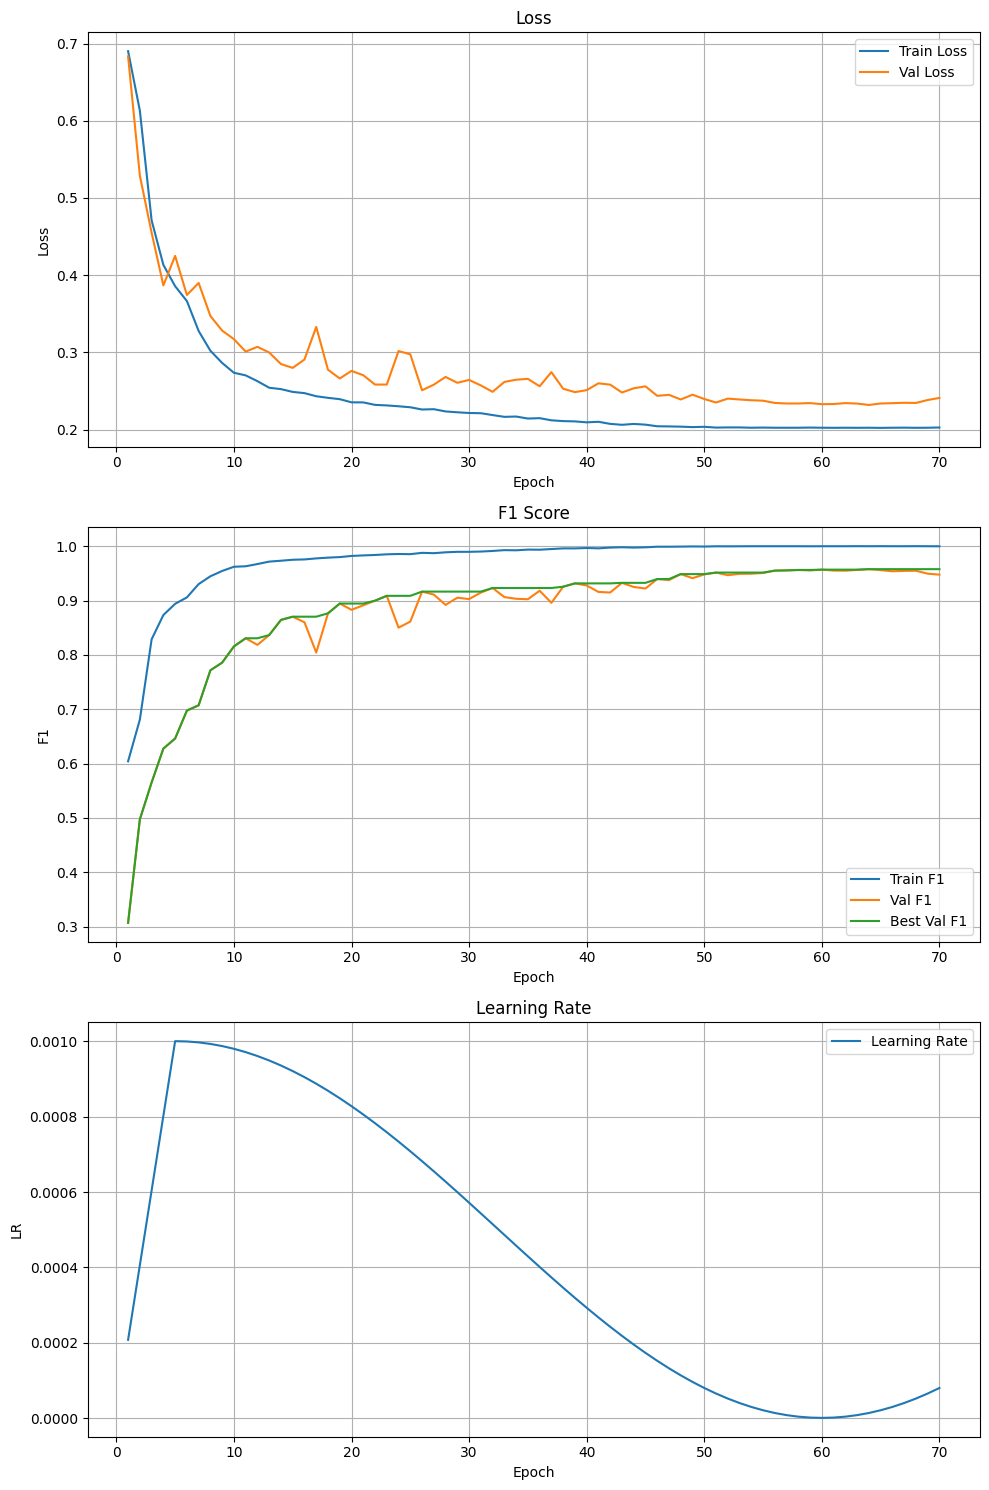

In [ ]:
import matplotlib.pyplot as plt

df = pd.read_csv("training_log.csv")

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

axes[0].plot(df["epoch"], df["train_loss"], label="Train Loss")
axes[0].plot(df["epoch"], df["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df["epoch"], df["train_f1"], label="Train F1")
axes[1].plot(df["epoch"], df["val_f1"], label="Val F1")
axes[1].plot(df["epoch"], df["best_val_f1"], label="Best Val F1")
axes[1].set_title("F1 Score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(df["epoch"], df["lr"], label="Learning Rate")
axes[2].set_title("Learning Rate")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("LR")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
model = FreqNet(
    num_classes=2,
).to(device)

model.load_state_dict(torch.load("./best_model.pth"))
model.eval()

FreqNet(
  (spatial_branch): SpatialCNN(
    (backbone): EfficientNet(
      (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNormAct2d(
        32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): SiLU(inplace=True)
      )
      (blocks): Sequential(
        (0): Sequential(
          (0): DepthwiseSeparableConv(
            (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (bn1): BatchNormAct2d(
              32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): SiLU(inplace=True)
            )
            (aa): Identity()
            (se): SqueezeExcite(
              (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (act1): SiLU(inplace=True)
              (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1

In [18]:
class TestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.files = sorted(
            os.listdir(image_dir),
            key=lambda x: int(os.path.splitext(x)[0])
        )
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]
        path = os.path.join(self.image_dir, filename)

        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, filename

In [19]:
test_dir="/kaggle/input/competitions/dataset/test_images"
test_dataset = TestDataset(test_dir, val_transform)
test_loader = DataLoader(test_dataset, batch_size=24, shuffle=False)

In [ ]:
all_idx = []
all_probs = []

with torch.no_grad():
    for images, filenames in tqdm(test_loader, desc="Inference", leave=True):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        idx = [int(os.path.splitext(f)[0]) for f in filenames]
        all_idx.extend(idx)
        all_probs.extend(probs.cpu().numpy())

different_probs = [0.3, 0.5, 0.7]

for threshold in np.arange(0.05, 0.2, 0.05):
    all_preds = (np.array(all_probs) > threshold).astype(int)

    submission = pd.DataFrame({
        "id": all_idx,
        "target_feature": all_preds
    })
    submission = submission.sort_values("id").reset_index(drop=True)

    filename = f"submission_threshold_{str(threshold).replace('.', '_')}.csv"
    submission.to_csv(filename, index=False)
    print(f"[threshold={threshold}] fake={all_preds.sum()} real={len(all_preds)-all_preds.sum()} → {filename}")

Inference:   0%|          | 0/417 [00:00<?, ?it/s]

[threshold=0.05] fake=8445 real=1555 → submission_threshold_0_05.csv
[threshold=0.1] fake=1628 real=8372 → submission_threshold_0_1.csv
[threshold=0.15000000000000002] fake=1617 real=8383 → submission_threshold_0_15000000000000002.csv
[threshold=0.2] fake=1611 real=8389 → submission_threshold_0_2.csv


In [ ]:
def get_probs(model, loader):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for images, filenames in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_probs)

def get_idx(loader):
    all_idx = []
    for _, filenames in loader:
        idx = [int(os.path.splitext(f)[0]) for f in filenames]
        all_idx.extend(idx)
    return all_idx

def make_tta_loader(transform):
    dataset = TestDataset(test_dir, transform=transform)
    return DataLoader(dataset, batch_size=24, shuffle=False, num_workers=4)

base_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

tta_transforms = [
    base_transform,
    transforms.Compose([
        transforms.Resize((384, 384)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
    ]),
    transforms.Compose([
        transforms.Resize((420, 420)),
        transforms.CenterCrop(384),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
    ]),
]

all_probs_tta = []

for i, transform in enumerate(tta_transforms):
    loader = make_tta_loader(transform)
    probs = get_probs(model, loader)
    all_probs_tta.append(probs)
    print(f"TTA {i+1}/{len(tta_transforms)} done | mean prob: {probs.mean():.4f}")

final_probs = np.mean(all_probs_tta, axis=0)

base_loader = make_tta_loader(base_transform)
all_idx = get_idx(base_loader)

for threshold in np.arange(0.3, 0.75, 0.05):
    all_preds = (final_probs > threshold).astype(int)
    submission = pd.DataFrame({
        "id": all_idx,
        "target_feature": all_preds
    })
    submission = submission.sort_values("id").reset_index(drop=True)
    filename = f"submission_tta_threshold_{str(round(threshold, 2)).replace('.', '_')}.csv"
    submission.to_csv(filename, index=False)
    print(f"[threshold={threshold:.2f}] fake={all_preds.sum()} real={len(all_preds)-all_preds.sum()} → {filename}")

TTA 1/3 done | mean prob: 0.1856
TTA 2/3 done | mean prob: 0.0890
TTA 3/3 done | mean prob: 0.0847
[threshold=0.30] fake=1565 real=8435 → submission_tta_threshold_0_3.csv
[threshold=0.35] fake=855 real=9145 → submission_tta_threshold_0_35.csv
[threshold=0.40] fake=686 real=9314 → submission_tta_threshold_0_4.csv
[threshold=0.45] fake=659 real=9341 → submission_tta_threshold_0_45.csv
[threshold=0.50] fake=635 real=9365 → submission_tta_threshold_0_5.csv
[threshold=0.55] fake=601 real=9399 → submission_tta_threshold_0_55.csv
[threshold=0.60] fake=573 real=9427 → submission_tta_threshold_0_6.csv
[threshold=0.65] fake=316 real=9684 → submission_tta_threshold_0_65.csv
[threshold=0.70] fake=133 real=9867 → submission_tta_threshold_0_7.csv


In [23]:
all_idx = []
with torch.no_grad():
    for images, filenames in tqdm(test_loader, desc="Getting idx", leave=True):
        idx = [int(os.path.splitext(f)[0]) for f in filenames]
        all_idx.extend(idx)

submission = pd.DataFrame({
    "id": all_idx,
    "target_feature": 1
})
submission = submission.sort_values("id").reset_index(drop=True)
submission.to_csv("submission_zeros.csv", index=False)
print(f"Сохранено: все предсказания = 0, строк = {len(submission)}")

Getting idx:   0%|          | 0/417 [00:00<?, ?it/s]

Сохранено: все предсказания = 0, строк = 10000
